## Loading libraries and data

Here we load the necessary libraries. Note that while `pandas`, `numpy`, `sklearn`, `statsmodels`, `nltk` come with Anaconda distribution, you will probably have to install `stargazer` (for printing regression tables) and `plotly` (data visualization) manually.

Some codes and explanations here have been borrowed from *Natural Language Processing* specialization on Coursera:

* https://www.coursera.org/specializations/natural-language-processing

In [1]:
#@title
# This is to install some packages
!pip install stargazer
!pip install plotly
# You can comment it out later

In [2]:
import pandas as pd      # Data frames
import numpy as np       # Fast matrix computations
import nltk              # Text processing

import statsmodels.api as sm
import plotly.express as px

# Notebook 3: DTM and regularization

Go through the notebook and do exercises. There will be topics for discussion in the end - we will discuss them in the next class.

By the end of this activity, you should

1. Learn how to clean and stem text data

2. Be able to convert text data to features by constructing the document-term matrix (DTM)

3. Implement regularization for logistic regression

The following command imports the CSV dataset using pandas:

In [3]:
# dataset = pd.read_csv('trump_twitter.csv')

#### Loading data from Google Drive - thanks to ChatGPT
# https://drive.google.com/file/d/1e4ILJx6XLX1piO7O5MseZJ1eZOn7fwOV/view?usp=sharing

import requests
from io import StringIO

# Set the file ID of the CSV file you want to load
file_id = "1e4ILJx6XLX1piO7O5MseZJ1eZOn7fwOV"

# Set the URL to download the file using the Drive API
url = f"https://drive.google.com/uc?id={file_id}&export=download"

# Make a GET request to download the file and decode the content
content = requests.get(url).content.decode("utf-8")

# Convert the string content to a pandas dataframe
dataset = pd.read_csv(StringIO(content))

print("Data dimensions =", dataset.shape)
print("Here is the head of the data:")
dataset.head()

Data dimensions = (41436, 7)
Here is the head of the data:


,source,text,created_at,retweet_count,favorite_count,is_retweet,id_str
0,Twitter for iPhone,Heading to Toledo Ohio for first Rally of the ...,01-09-2020 22:55:41,10544.0,55906,false,1.215407e+18
1,Twitter for iPhone,95% Approval Rating in the Republican Party. T...,01-09-2020 22:49:55,9996.0,66007,false,1.215405e+18
2,Twitter for iPhone,Smart analysis I fully agree! https://t.co/0YM...,01-09-2020 22:34:17,6962.0,25685,false,1.215401e+18
3,Twitter for iPhone,RT @StewardshipAmer: @realDonaldTrump All citi...,01-09-2020 22:13:13,3686.0,0,true,1.215396e+18
4,Twitter for iPhone,RT @MatthewJshow: @realDonaldTrump The choice ...,01-09-2020 22:12:26,2805.0,0,true,1.215396e+18


And here is some simple description

In [4]:
dataset.describe()

,retweet_count,id_str
count,41432.000000,4.142900e+04
mean,7074.755117,6.779099e+17
std,11487.450679,3.274896e+17
min,0.000000,1.698309e+09
25%,29.000000,3.875589e+17
50%,727.500000,6.224078e+17
75%,12131.250000,1.003739e+18
max,369530.000000,1.215407e+18


## Data exploration

First, let's do some sanity check - look at the values of "is_retweet". They are supposed to be true or false. Below are counts of unique values in the "is_retweet" column

In [5]:
dataset.is_retweet.value_counts()

,count
is_retweet,
false,39458
true,1913
115846232714391552,1
101013255950053376,1
98482327390396416,1


In fact, there are three exceptional values that are probably some kind of an error. We will just remove them.

In [6]:
dataset = dataset[dataset["is_retweet"].isin(["false", "true"])]
dataset.shape

(41371, 7)

Note that when you work with a new dataset needed for your job or yourp project, you will need to do a more detailed analysis.

Let's now look at the histogram of "retweet_count":

In [7]:
fig = px.histogram(dataset, x = 'retweet_count', nbins = 30)
fig.update_layout(xaxis_title='Retweet count', yaxis_title = "Count", bargap = 0.1)
fig.show()

Note that the distribution of retweet count is highly skewed. There are some extremely highly influential tweets but most are not. It probably doesn't make a lot of sense to look at the raw retweet count - let us look at the logarithm of retweet count instead.

### Exercise 1

Plot the histogram of the logarithm of retweet count. You will need to think what to do with tweets that were not retweeted at all

In [8]:
# Change this so that the error message disappears
# dataset["log_retweet_count"] = np.where(
#     dataset["retweet_count"] != 0.0,  # Condition
#     np.log(dataset["retweet_count"]),  # Value if condition is True
#     0  # Value if condition is False
# )

dataset["log_retweet_count"] = np.log(dataset["retweet_count"].where(dataset["retweet_count"] > 0, 1))
dataset.loc[dataset["retweet_count"] == 0, "log_retweet_count"] = 0


fig = px.histogram(dataset, x = 'log_retweet_count', nbins=30)
fig.update_layout(xaxis_title='Log(Retweet count)', yaxis_title = "Count", bargap = 0.1)
fig.show()


# Data processing

Here, we will clean (remove non-alphabet symbols, change everything to lower cases etc) and stem (change all words with the same stemp, like "learn", "learner", and "learning" to just the stem, i.e., "learn") the tweets.

First we will load the necessary libraries

In [9]:
# download the stopwords from NLTK
nltk.download('stopwords')

import re                                  # library for regular expression operations
import string                              # for string operations

from nltk.corpus import stopwords          # module for stop words that come with NLTK
from nltk.stem import PorterStemmer        # module for stemming
from nltk.tokenize import TweetTokenizer   # module for tokenizing strings

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## Tokenization

To tokenize means to split the strings into individual words without blanks or tabs. In this same step, we will also convert each word in the string to lower case. The [tokenize](https://www.nltk.org/api/nltk.tokenize.html#module-nltk.tokenize.casual) module from NLTK allows us to do these easily:

In [10]:
tweet = dataset["text"][2]
print('Here is a tweet:')
print(tweet)
print('Type of variable "tweet" is', type(tweet))

# instantiate tokenizer class
tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True,
                               reduce_len=True)

# tokenize tweets
tweet_tokens = tokenizer.tokenize(tweet)

print()
print('Tokenized tweet:')
print(tweet_tokens)
print('Type of variable "tweet_tokens" is', type(tweet_tokens))

Here is a tweet:
Smart analysis I fully agree! https://t.co/0YMU7GunDt
Type of variable "tweet" is <class 'str'>

Tokenized tweet:
['smart', 'analysis', 'i', 'fully', 'agree', '!', 'https://t.co/0YMU7GunDt']
Type of variable "tweet_tokens" is <class 'list'>


## Removing stopwords and punctuation

The next step is to remove stopwords and punctuation. Stopwords are words that don't add significant meaning to the text. Note that whether or not we need to remove stopwords depends on the task. We probably don't need them for text classification, but we certainly need them for machine translation.

In [11]:
#Import the english stop words list from NLTK
stopwords_english = stopwords.words('english')

print('Stopwords\n')
print(stopwords_english)

print('\nPunctuation\n')
print(string.punctuation)

Stopwords

['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so'

Here is how it works:

In [12]:
print('Here is a tweet:')
print(tweet)

tweets_clean = []

for word in tweet_tokens: # Go through every word in your tokens list
    if (word not in stopwords_english and  # remove stopwords
        word not in string.punctuation):  # remove punctuation
        tweets_clean.append(word)

print('After removing stopwords and punctuation:')
print(tweets_clean)

Here is a tweet:
Smart analysis I fully agree! https://t.co/0YMU7GunDt
After removing stopwords and punctuation:
['smart', 'analysis', 'fully', 'agree', 'https://t.co/0YMU7GunDt']


## Stemming

Stemming is the process of converting a word to its most general form, or stem. This helps in reducing the size of our vocabulary.

Consider the words:
 * **learn**
 * **learn**ing
 * **learn**ed
 * **learn**t

All these words are stemmed from its common root **learn**. However, in some cases, the stemming process produces words that are not correct spellings of the root word. For example, **happi** and **sunni**. That's because it chooses the most common stem for related words. For example, we can look at the set of words that comprises the different forms of happy:

 * **happ**y
 * **happi**ness
 * **happi**er

We can see that the prefix **happi** is more commonly used. We cannot choose **happ** because it is the stem of unrelated words like **happen**.

NLTK has different modules for stemming and we will be using the [PorterStemmer](https://www.nltk.org/api/nltk.stem.html#module-nltk.stem.porter) module which uses the [Porter Stemming Algorithm](https://tartarus.org/martin/PorterStemmer/). Let's see how we can use it in the cell below.

In [13]:
# Instantiate stemming class
stemmer = PorterStemmer()

# Create an empty list to store the stems
tweets_stem = []

for word in tweets_clean:
    stem_word = stemmer.stem(word)  # stemming word
    tweets_stem.append(stem_word)  # append to the list


print('Here is a tweet:')
print(tweet)

print('Stemmed words:')
print(tweets_stem)

Here is a tweet:
Smart analysis I fully agree! https://t.co/0YMU7GunDt
Stemmed words:
['smart', 'analysi', 'fulli', 'agre', 'https://t.co/0ymu7gundt']


## All together

Here we will write a function whose input is a string and whose output is the same string changed to lower case, with removed punctuation, stopwords and hyperlinks, and all words changed to their stems.

In [14]:
def process_tweet(tweet):
    """Process tweet function.
    Input:
        tweet: a string containing a tweet
    Output:
        tweets_clean: a list of words containing the processed tweet
        Modified: the string with the processed tweet

    """
    stemmer = PorterStemmer()
    stopwords_english = stopwords.words('english')
    # remove stock market tickers like $GE
    tweet = re.sub(r'\$\w*', '', tweet)
    # remove old style retweet text "RT"
    tweet = re.sub(r'^RT[\s]+', '', tweet)
    # remove hyperlinks
    tweet = re.sub(r'https?://[^\s\n\r]+', '', tweet)
    # remove hashtags
    # only removing the hash # sign from the word
    tweet = re.sub(r'#', '', tweet)
    # tokenize tweets
    tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True,
                               reduce_len=True)
    tweet_tokens = tokenizer.tokenize(tweet)

    tweets_clean = []
    for word in tweet_tokens:
        if (word not in stopwords_english and  # remove stopwords
                word not in string.punctuation):  # remove punctuation
            # tweets_clean.append(word)
            stem_word = stemmer.stem(word)  # stemming word
            tweets_clean.append(stem_word)

    return ' '.join(tweets_clean)

print('Here is a tweet:')
print(tweet)
print('Here is the processed tweet:')
print(process_tweet(tweet))

Here is a tweet:
Smart analysis I fully agree! https://t.co/0YMU7GunDt
Here is the processed tweet:
smart analysi fulli agre


In [15]:
### This may take some time
### Note the pandas method "apply" - it has two arguments:
### the first is a function that is applied, the second is the axis
### (axis = 0 to apply to all entries in a given row and axis = 1 to apply to all entries in a given column.
### In this case we apply the function "process_tweet" to all entries in the column labelled "text":
dataset["clean_text"] = dataset["text"].apply(process_tweet, 1)
dataset.head()

<ipython-input-15-d26802b808ab>:6: FutureWarning:

the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.



,source,text,created_at,retweet_count,favorite_count,is_retweet,id_str,log_retweet_count,clean_text
0,Twitter for iPhone,Heading to Toledo Ohio for first Rally of the ...,01-09-2020 22:55:41,10544.0,55906,false,1.215407e+18,9.263312,head toledo ohio first ralli year tremend crow...
1,Twitter for iPhone,95% Approval Rating in the Republican Party. T...,01-09-2020 22:49:55,9996.0,66007,false,1.215405e+18,9.209940,95 approv rate republican parti thank
2,Twitter for iPhone,Smart analysis I fully agree! https://t.co/0YM...,01-09-2020 22:34:17,6962.0,25685,false,1.215401e+18,8.848222,smart analysi fulli agre
3,Twitter for iPhone,RT @StewardshipAmer: @realDonaldTrump All citi...,01-09-2020 22:13:13,3686.0,0,true,1.215396e+18,8.212297,citizen includ black american support presid …
4,Twitter for iPhone,RT @MatthewJshow: @realDonaldTrump The choice ...,01-09-2020 22:12:26,2805.0,0,true,1.215396e+18,7.939159,choic clear novemb continu prosper presid trum...


# Organizing the data

Imagine the following scenario: you are an adviser to Mr Donald Trump and your objective is to help him to write influential tweets. You need to look at existing tweets and figure out whether there are special words or topics that are associated with a tweet being retweeted many times, i.e., going viral.

Here we will organize the data, i.e., features and response variable according to the business problem we have in mind, i.e., helping Mr Donald Trum to write influential tweets. First, we will construct the response variable and then we will look at the features (predictors).

## Response variable

Instead of predicting the retweet count or its logarithm, i.e., doing a regression problem, let's convert it to a classification problem. In other words, we will predict whether a tweet becomes viral.

In exercise 1, you should have seen a nice trimodal distribution of the retweet log-count with peaks near 0, 3, and 9.5. Let's use the third peak as the definition of "viral" (this is somewhat arbitrary, but anyway). We'll define a "viral" tweet as a tweet whose retweet log-count is at least 7.75 (the "low point" between the second peak and the third peak in the histogram).

In other words, we define the new variable "viral" as follows:

$$
\mathrm{viral} =
\begin{cases}
0, & \mbox{retweet count} < e^{7.75},\\
1, & \mbox{retweet count} \ge e^{7.75},\\
\end{cases}
$$

Below are counts of viral and non-viral tweets:

In [16]:
Y = np.array(0.0 + (dataset["retweet_count"] > np.exp(7.75)))
print("There are", int(np.sum(Y)), "viral tweets")
print("There are", int(np.sum(1-Y)), "non-viral tweets")

There are 17582 viral tweets
There are 23789 non-viral tweets


## Features

Here we will create the document-term matrix and use its columns as features.

In [17]:
from sklearn.feature_extraction.text import CountVectorizer

vec = CountVectorizer()
X = vec.fit_transform(dataset["clean_text"])
DTM = pd.DataFrame(X.toarray(), columns=vec.get_feature_names_out())
print("Sample of DTM:")
print(DTM.iloc[[10000, 20000, 30000] , [10000, 15000, 20000]])
print("dim(DTM) =", DTM.shape)

Sample of DTM:
       boyfriend  hokey  raptor
10000          0      0       0
20000          0      0       0
30000          0      0       0
dim(DTM) = (41371, 25144)


Note that the DTM is huge. It has too many features and a lot of them are probably not very useful. There should be some words that appear only once or twice in the whole corpus and we can't possibly rely on such words for prediction. Besides, training a machine-learning model with such a large number of featues may be too time-consuming.

In [18]:
term_freq = DTM.sum(axis = 0)
print("Here is a sample of term frequencies:")
print(term_freq[[10000, 15000, 20000]])

Here is a sample of term frequencies:
boyfriend    3
hokey        1
raptor       1
dtype: int64


<ipython-input-18-bb32875fa7ad>:3: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



In [19]:
term_freq

,0
00,601
000,7
00011520,1
0003969,1
00055042,1
...,...
초소는,1
초소에서,1
한국전쟁,1
２０サミットが開幕しました,1


### Exercise 2

How many words are there that appear only once? How many words are there that appear only twice? Plot the bar chart showing 20 most frequent words and their frequencies

In [20]:
#### Update this
print("There are", np.sum(term_freq == 1), "terms that appear only once")
print("There are", np.sum(term_freq == 2), "terms that appear only twice")

There are 14828 terms that appear only once
There are 2371 terms that appear only twice


In [21]:
df_term_freq = pd.DataFrame(data = {'term': DTM.columns.values, 'freq': term_freq})
df_term_freq = df_term_freq.sort_values(["freq"], ascending = False)
df_term_freq

,term,freq
trump,trump,6930
great,great,6407
thank,thank,5074
presid,presid,3641
fals,fals,3048
...,...,...
615,615,1
6149591160,6149591160,1
6148544784,6148544784,1
hotdog,hotdog,1


In [22]:
### Update this:
# df_term_freq = pd.DataFrame(data = {'term': DTM.columns.values, 'freq': 0})
# df_term_freq = df_term_freq.sort_values(["freq"], ascending = False)
df_term_freq = pd.DataFrame(data = {'term': DTM.columns.values, 'freq': term_freq})
df_term_freq = df_term_freq.sort_values(["freq"], ascending = False)


fig = px.bar(df_term_freq.head(20), x='term', y='freq')
fig.show()

___END OF EXERCISE 2___

Let us only use words that appear more often than a certain threshold in the model. The choice of the threshold is probably somewhat arbitrary.

In [23]:
threshold_for_freq = 500
print("Frequent terms are terms that appear at least", threshold_for_freq, "times")
frequent_terms = DTM.columns.values[term_freq >= threshold_for_freq]
print("Found" , frequent_terms.shape[0], "frequent terms")
print("Some frequent terms are")
print(frequent_terms[95:115])

Frequent terms are terms that appear at least 500 times
Found 172 frequent terms
Some frequent terms are
['militari' 'million' 'money' 'mr' 'much' 'must' 'nation' 'need' 'never'
 'new' 'news' 'next' 'nice' 'night' 'noth' 'obama' 'one' 'peopl' 'pleas'
 'polit']


Now we will create a subset of the DTM by choosing only columns that contain frequent terms. This trimmed DTM will serve as the matrix of features.

In [24]:
DTM_trimmed = DTM[frequent_terms]
print("Sample of X:")
print(DTM_trimmed.iloc[[12, 19, 6568, 8128], [75, 97, 110]])
print("dim(X) =", DTM_trimmed.shape)

Sample of X:
      impeach  money  obama
12          1      0      0
19          0      0      1
6568        0      1      1
8128        0      0      2
dim(X) = (41371, 172)


## Modelling

## Logistic regression

We will train a logistic model that uses columns of the DTM as features.

In [25]:
mod1 = sm.Logit(Y, DTM_trimmed).fit()
print(mod1.summary())

Optimization terminated successfully.
         Current function value: 0.530380
         Iterations 12
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                41371
Model:                          Logit   Df Residuals:                    41199
Method:                           MLE   Df Model:                          171
Date:                Fri, 24 Jan 2025   Pseudo R-squ.:                  0.2221
Time:                        16:38:19   Log-Likelihood:                -21942.
converged:                       True   LL-Null:                       -28209.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
00                        0.5587      0.116      4.816      0.000       0.331       0

Note that there are just too many parameters in the model. Below we print top 20 terms whose coefficient is the largest in absolute value. To do it, we will extract the model's coefficients, sort them according to the absolute value and then flip the result since by default they will be sorted from smallest to largest. Then we will print the top 20.

In [26]:
mod1.params[np.argsort(-np.abs(mod1.params))].head(20)

<ipython-input-26-7e2a0fc93fbf>:1: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



,0
2013,-4.124952
impeach,3.533949
fake,2.636981
democrat,2.089583
dem,2.029883
hillari,1.738211
clinton,1.645902
cours,-1.608296
via,-1.584034
golf,-1.558310


And now we will compute the accuracy of the model

[[18748  5041]
 [ 6410 11172]]


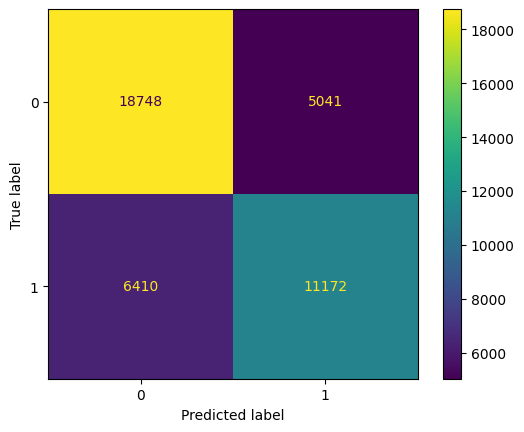

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
mod1_preds = mod1.predict(DTM_trimmed)
cm = confusion_matrix(Y, 0. + (mod1_preds > 0.5), labels=[0, 1])
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

### Exercise 3

What is the overall accuracy of our model? And what is the overall accuracy of the baseline model that predicts that all tweets are non-viral?

In [28]:
print(cm[0, 1])

5041


In [29]:
#### Update this so that it prints correctly computed accuracies
#### Hint: you will need the function np.diag
print("The overall accuracy of logistic model is", np.round(np.sum(np.diag(cm)) / np.sum(cm), 3))
print("The overall accuracy of baseline model is", np.round(np.sum(Y) / np.sum(cm), 3))

The overall accuracy of logistic model is 0.723
The overall accuracy of baseline model is 0.425


## Regularized model

The loss function for the $l_1$-regularized logistic regression is
$$
L(\beta)=-\sum_{i=1}^{N}\left(y^i\log p(x^i)+ (1-y^i)\log(1-p(x^i))\right)+
\lambda\sum_{i=1}^{p}|\beta_i|
$$
Here, $\lambda$ is a hyper-parameter. Normally, there should be some procedure to find the best value of $\lambda$ (it is not found via gradient-descent like $\beta$). Here is how can just assign the value to $\lambda$ and train the model:

In [30]:
from time import time
start = time()

L = 150.0
print("Lambda =", L)
mod2 = sm.Logit(Y, DTM_trimmed).fit_regularized(alpha = L, L1_wt = 1)
print("This took %0.3fs" % (time() - start))
print("The number of nonzero coefficients is", np.count_nonzero(mod2.params), "out of ", DTM_trimmed.shape[1])
# print(mod2.summary())

Lambda = 150.0
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.6492074344332218
            Iterations: 132
            Function evaluations: 132
            Gradient evaluations: 132
This took 36.654s
The number of nonzero coefficients is 36 out of  172


Smaller values of $\lambda$ produce more non-zero coefficients and take longer time to train.

### Exercise 4

Print nonzero coefficients of the regularized model sorted in the order of decreasing absolute value

In [31]:
### Update these codes
nonzero_coefs = mod2.params[np.abs(mod2.params) >= 0.5]
nonzero_coefs[np.argsort(nonzero_coefs)]

<ipython-input-31-9c14c2ead037>:3: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



,0
donald,-0.757308
android,-0.718824
run,-0.651958
obama,-0.632714
trump,-0.504533
border,0.510500
impeach,0.525650
state,0.693206
hillari,0.741464
fake,0.828342


## Question to think about

Discuss these questions with your teammates and enter your team's answer to WooClap - we will then discuss with the whole class.

### Question 1 - big conceptual error

There is a very serious conceptual error in the approach implemented in this notebook. What is the error?

*no train-test split*

### Question 2 - variable selection

Working with the un-regularized logistic regression, we identified the most important variables as the ones whose coefficient in the model has the largest absolute value. Is it a correct strategy here? Will this be a correct strategy for other datasets? If it's not a correct strategy, suggest an alternative strategy to identify most important variables in the logistic model.

### Question 3 - hidden hyperparameter

There is, in fact, a hidden hyperparameter that we didn't bother to find the optimal value of here (not $\lambda$). What is this hidden hyperparameter?

__END OF QUESTION 3__

Here are regression tables if you are intersted. Note that model 2 has a lot of zero coefficients that don't have a standard error. Besides, coefficients of model 2 are smaller in magnitude than coefficients of model 1, which is expected.

In [32]:
from stargazer.stargazer import Stargazer, LineLocation
stargazer = Stargazer([mod1, mod2])
stargazer